In [1]:
#create a data set
# Example we are taking daily electricity consumption of 20 houses
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

data= np.array([4.1,4.3,4.8,5.0,5.2,5.5,6.0,6.2,4.9,5.1,5.3,5.8,6.1,4.7,5.4,5.6,4.6,5.3,5.9,5.0])

In [2]:
#step1: calculate mean and variance
mean= np.mean(data)
variance= np.var(data)
print("Mean:", mean)
print("Variance:", variance)

Mean: 5.24
Variance: 0.3274


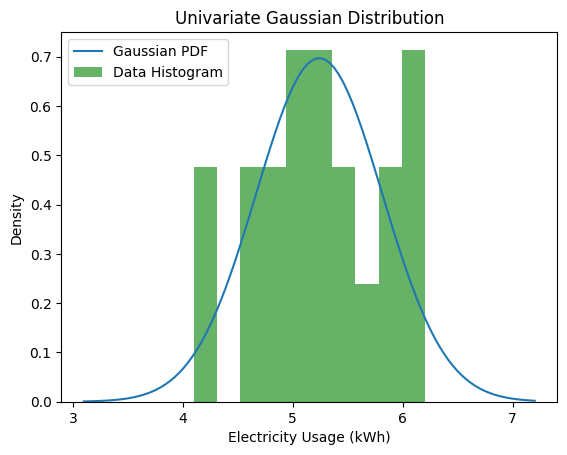

In [8]:
X=np.linspace(min(data)-1, max(data)+1, 100)
pdf= norm.pdf(X, mean, np.sqrt(variance))

plt.plot(X, pdf, label='Gaussian PDF')
plt.hist(data, bins=10, density=True, alpha=0.6, color='g', label='Data Histogram') 
plt.title('Univariate Gaussian Distribution')
plt.xlabel('Electricity Usage (kWh)')
plt.ylabel('Density')
plt.legend()
plt.show()


Mean Vector:
 [4.94807674 2.00669138]
Covariance Matrix:
 [[ 0.20619247 -0.01772313]
 [-0.01772313  0.0818536 ]]


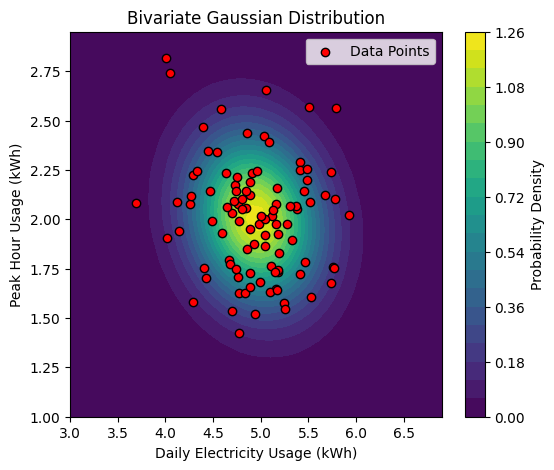

In [12]:
#Task2:
#understand covariance and elliptical distribution
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(42)

#generate data
daily=np.random.normal(5,0.5,100)
# weekly=np.random.normal(35,3,100)
peak=np.random.normal(2,0.3,100)

X=np.column_stack((daily, peak))

#estimate parameters
mean_vector=np.mean(X, axis=0)
cov_matrix=np.cov(X.T)

print("Mean Vector:\n", mean_vector)
print("Covariance Matrix:\n", cov_matrix)

#create gaussian model
rv= multivariate_normal(mean_vector, cov_matrix)

#create grid for plotting
x, y= np.mgrid[3:7:0.1, 1:3:0.05]  #1:3:0.05
pos= np.dstack((x, y))

#plotting
plt.figure(figsize=(6,5))
plt.contourf(x, y, rv.pdf(pos), levels=20,cmap='viridis')
plt.colorbar(label='Probability Density')

plt.scatter(X[:,0], X[:,1], c='red', edgecolor='k', label='Data Points')

plt.title('Bivariate Gaussian Distribution')
plt.xlabel('Daily Electricity Usage (kWh)')
plt.ylabel('Peak Hour Usage (kWh)')
plt.legend()
plt.show()